# 朴素贝叶斯：从「看邻居」换成「算概率」

**课程 0006 配套练习** · 内核：`deeplearning`

前置：课程 0004（逻辑回归）。本课把视角从<b>判别模型</b>换到<b>生成模型</b>：

- 逻辑回归：直接建模 $P(y\mid x)$ ——「给定特征，哪个类」。（判别）
- 朴素贝叶斯：建模 $P(x\mid y)$ 与 $P(y)$，再用贝叶斯公式反推后验。（生成）

> 读完后请回答：为什么一个「假设几乎必然错误」的模型（条件独立），实战中却很好用？


## 问题设定：两类高斯，方差不同

类 0 的方差小、类 1 的方差大。方差不同正是本课的关键——它会让贝叶斯分类边界<strong>变弯</strong>。


X: (300, 2)  类数: 2


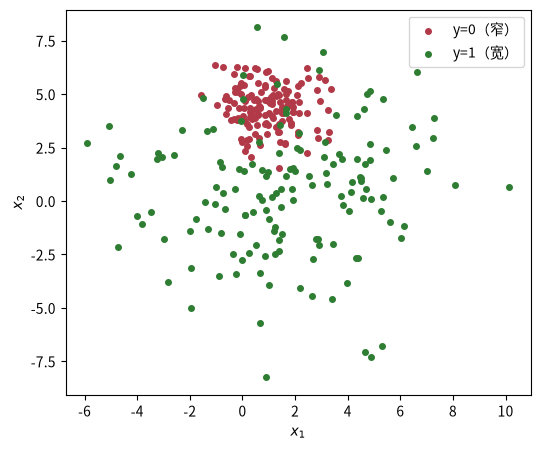

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=2, cluster_std=[1.0, 3.0], random_state=0)
print("X:", X.shape, " 类数:", len(np.unique(y)))

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=16, label="y=0（窄）")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=16, label="y=1（宽）")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.show()

## 贝叶斯公式：生成视角

$$P(y\mid x) = \frac{P(x\mid y)P(y)}{P(x)}$$

- $P(y)$：**先验** —— 类出现的比例
- $P(x\mid y)$：**似然** —— 该类下特征长这样（本）的概率
- $P(x)$：与类别无关，分类时可不看（每类都一样）

对每个新样本，我们算「每类的后验」，取最大者。因为 $P(x)$ 对各类相同，只要比较
$P(x\mid y)P(y)$ 的相对大小即可。

## 「朴素」在哪：条件独立假设

真实特征通常互相相关。朴素贝叶斯<strong>假设在给定类别时特征条件独立</strong>：

$$P(x\mid y) = P(x_1\mid y)P(x_2\mid y)\cdots P(x_d\mid y)$$

好处：本来要估计 $2^d$ 个联合概率，现在只需 $d$ 个一维分布——参数数量从指数降到线性。
代价：假设几乎总不成立。后面练习 S1 会回答「为什么还能用」。


## 手写高斯朴素贝叶斯

连续特征：假设每类的每个特征服从一维高斯分布，用训练数据估计均值与方差（这就是「策略」：极大似然）。

训练「算法」就是统计——每类的先验、每类每特征的均值/方差。预测时在<b>对数空间</b>算后验避免下溢。


In [16]:
def fit_gauss_nb(X_train, y_train):
    """估计参数：先验 P(y) 和 每类每特征的 (μ, σ)。返回 (classes, priors, params)。"""
    classes = np.unique(y_train)
    priors = {k: float(np.mean(y_train == k)) for k in classes}
    params = {}
    for k in classes:
        Xk = X_train[y_train == k]
        params[k] = (Xk.mean(axis=0), Xk.std(axis=0, ddof=0) + 1e-9)  # MLE，加 eps 防除零
    return classes, priors, params

def predict_gauss_nb(classes, priors, params, X_test):
    """对数后验取最大：log P(y) + Σ log P(x_j|y)。"""
    preds = []
    for xt in X_test:
        best_k, best_lp = None, -np.inf
        for k in classes:
            mu, sd = params[k]
            logp_x = np.sum(-0.5 * np.log(2 * np.pi * sd**2) - 0.5 * ((xt - mu) / sd) ** 2)
            lp = np.log(priors[k]) + logp_x
            if lp > best_lp:
                best_k, best_lp = k, lp
        preds.append(best_k)
    return np.array(preds)

classes, priors, params = fit_gauss_nb(X, y)
print("先验 P(y)：", {int(k): round(v, 3) for k, v in priors.items()})
for k in classes:
    mu, sd = params[k]
    print(f"类 {int(k)}：μ = {np.round(mu, 3)}，σ = {np.round(sd, 3)}")
print("回代准确率：", round(float(np.mean(predict_gauss_nb(classes, priors, params, X) == y)), 3))

先验 P(y)： {0: 0.5, 1: 0.5}
类 0：μ = [0.917 4.379]，σ = [0.999 0.984]
类 1：μ = [1.616 0.484]，σ = [3.044 2.934]
回代准确率： 0.94


## 决策边界：贝叶斯是曲线，逻辑回归是直线

两类方差不同 ⇒ 后验相等的点构成<b>二次曲线</b>。这就是生成模型的「模型」与判别模型的区别。


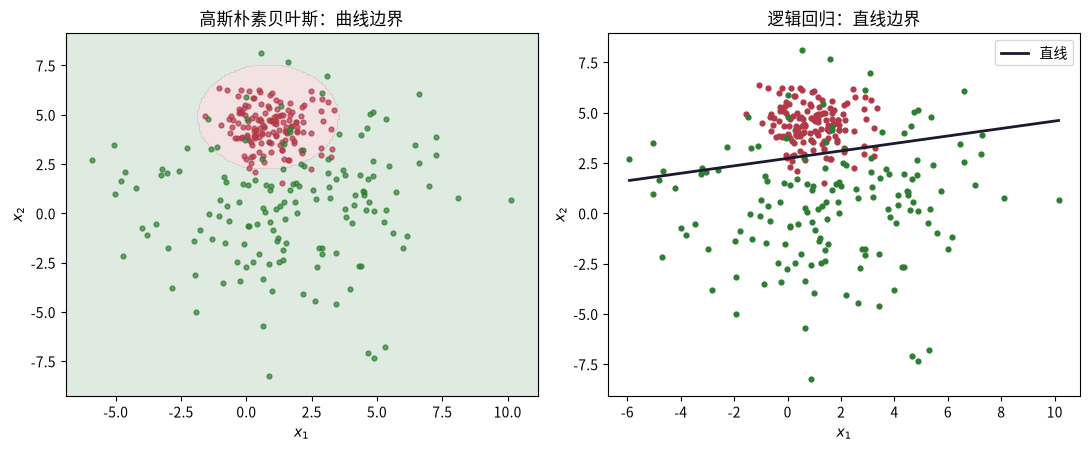

In [17]:
def plot_gauss_nb_boundary(X, y, ax, title):
    classes, priors, params = fit_gauss_nb(X, y)
    x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    x2 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
    xx, yy = np.meshgrid(x1, x2)
    Z = predict_gauss_nb(classes, priors, params, np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=1, colors=["#b23a48", "#2e7d32"], alpha=0.15)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=12, alpha=0.7)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=12, alpha=0.7)
    ax.set_title(title); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_gauss_nb_boundary(X, y, axes[0], "高斯朴素贝叶斯：曲线边界")

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X, y)
w, b = lr.coef_.ravel(), lr.intercept_[0]
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
axes[1].scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=12)
axes[1].scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=12)
axes[1].plot(x1, -(w[0] * x1 + b) / w[1], color="#1a1a2e", lw=2, label="直线")
axes[1].set_title("逻辑回归：直线边界"); axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$"); axes[1].legend()
plt.tight_layout(); plt.show()

## 拉普拉斯平滑：别让概率变零

离散特征（如文本里的词）用频率估计概率。问题：训练里没见过的「特征-类」组合概率为 0，
会让整个后验塌成 0。加<b>拉普拉斯平滑</b>：

$$P(x_j = v \mid y=k) = \frac{\text{count}(x_j=v,\, y=k) + \alpha}{N_k + \alpha \cdot V_j}$$

$\alpha$ 是平滑系数（常取 1），$V_j$ 是第 j 个特征取值个数。


## 迷你垃圾邮件分类：朴素贝叶斯的看家本领

经典的文本分类用法：词袋（bag of words）。每个词是「特征」，看它在某类里出现多少次。


In [ ]:
# 迷你语料：7 条消息，标签 1=垃圾 0=正常
corpus = [
    ("免费 中奖 点击 链接", 1),
    ("中奖 恭喜 快 来", 1),
    ("点击 领取 大奖", 1),
    ("今天 开会 讨论 项目", 0),
    ("会议 安排 在 下午", 0),
    ("报告 已经 写好", 0),
    ("明天 项目 进度 会", 0),
]
test_msg = ["中奖 链接 免费 比特币"]
test_msg = ["明天 项目 进度 比特币"]

# 分词
train_texts = [t.split() for t, _ in corpus]        # 拿到分词
train_labels = np.array([lb for _, lb in corpus])   # 拿到对应的标签
vocab = sorted({w for words in train_texts for w in words})     # 给单词排序
V = len(vocab)
print("词表：", vocab, " V =", V)
for v in vocab:
    print(v, end=" | ")
print()
    
# 词->索引
w2i = {w: i for i, w in enumerate(vocab)}

def multinomial_nb(train_texts, train_labels, alpha=1.0):   # 多项式朴素贝叶斯(通过计数作为特征，多用于文本分类)，alpha=1.0 是拉普拉斯平滑参数
    """返回每类先验、每类每词平滑计数。"""
    priors = {k: float(np.mean(train_labels == k)) for k in [0, 1]}     # 算垃圾邮箱和正常邮箱的先验概率
    counts = {k: np.zeros(V) for k in [0, 1]}   # 初始化每类每词的计数
    for words, lb in zip(train_texts, train_labels):    # 统计正常邮箱和垃圾邮箱中每个词出现的次数
        for w in words:
            counts[lb][w2i[w]] += 1
    logp = {}
    for k in [0, 1]:
        total = counts[k].sum() + alpha * V
        with np.errstate(divide="ignore", invalid="ignore"):
            logp[k] = np.log((counts[k] + alpha) / total)
    return priors, logp

priors, logp = multinomial_nb(train_texts, train_labels)
for k in [0, 1]:
    top = np.argsort(logp[k])[::-1][:3]
    print(f"类{k} 概率最高的词：", [(vocab[i], round(logp[k][i], 2)) for i in top])

# 预测测试消息
def predict_text(words, priors, logp):
    scores = {}
    for k in [0, 1]:
        s = np.log(priors[k])
        for w in words:
            if w in w2i:
                s += logp[k][w2i[w]]
            else:
                s += np.log(0.01)   # 未登录词给个很小的概率，不判死
        scores[k] = s
    return max(scores, key=scores.get), scores  # 返回预测标签(最大的分数对应的类别，这里只有两类)和每类的对数得分

# for i in range(30):
lab, scores = predict_text(test_msg[0].split(), priors, logp)
print(f"\n测试消息 {test_msg[0]!r} → 预测为 {'垃圾' if lab else '正常'}（对数得分 {np.round(list(scores.values()), 2)}）")

词表： ['下午', '中奖', '今天', '会', '会议', '免费', '写好', '在', '大奖', '安排', '已经', '开会', '快', '恭喜', '报告', '明天', '来', '点击', '讨论', '进度', '链接', '项目', '领取']  V = 23
下午 | 中奖 | 今天 | 会 | 会议 | 免费 | 写好 | 在 | 大奖 | 安排 | 已经 | 开会 | 快 | 恭喜 | 报告 | 明天 | 来 | 点击 | 讨论 | 进度 | 链接 | 项目 | 领取 | 
类0 概率最高的词： [('项目', np.float64(-2.54)), ('讨论', np.float64(-2.94)), ('进度', np.float64(-2.94))]
类1 概率最高的词： [('点击', np.float64(-2.43)), ('中奖', np.float64(-2.43)), ('链接', np.float64(-2.83))]

测试消息 '明天 项目 进度 比特币' → 预测为 正常（对数得分 [-13.59 -16.03]）


## 练习（S 理解 / M 动手 / H 挑战）

**S1.** 条件独立假设几乎总不成立，为什么朴素贝叶斯实战表现却不错？（提示：分类只需要后验的 argmax，不需要精确概率。）

**S2.** 方差不同为什么让边界变弯？把两类 `cluster_std` 都改成 1.0 重画边界，看它变成什么形状，并解释。

**M1.** 用 sklearn 的 `GaussianNB` 对同一数据训练，和手写版对比准确率（应当完全一致）。

**M2.** 在文本例子里把 `alpha` 从 0 扫到 5，观察类内词的平滑概率如何变化；`alpha=0` 时如果测试消息里出现训练没见过的词，会发生什么？

**H1.** 实现<strong>伯努利朴素贝叶斯</strong>：不看词频，只看「词是否出现」（0/1）。在同一语料上对比它与多项式版对测试消息的判定。

**H2.** 给语料加一条「训练时未见过的新词」的测试消息（如「中奖 比特币」中「比特币」不在词表），说明平滑如何救场，并讨论未登录词（OOV）的一般处理办法。


In [ ]:
# pass  # 练习区（S1/S2）
# 不要求概率绝对值准，只要相对大小顺序正确就可以完成分类

# 当两个类别高斯分布方差（协方差）不一样，决策边界是二次曲线（双曲线 / 弯曲）

In [ ]:
# pass  # 练习区（M1/M2）
from sklearn.naive_bayes import GaussianNB, MultinomialNB
model = GaussianNB().fit(X, y)
y_pred = model.predict(X)
print("回代准确率：", round(float(np.mean(y_pred == y)), 3))



回代准确率： 0.94


In [ ]:
# pass  # 练习区（H1/H2）
# 重复堆砌同一个词的垃圾消息：多项式会给很高分数；伯努利不受重复词影响；
# 短文本，伯努利效果往往不错；长文本多项式通常更占优。

## 小结：生成 vs 判别

| | 朴素贝叶斯（生成） | 逻辑回归（判别） |
|---|---|---|
| 建模 | P(x\|y)·P(y) 再反推 | 直接 P(y\|x) |
| 边界 | 曲线（方差不同时） | 直线 |
| 训练 | 统计参数（快，可在线） | 梯度下降迭代 |
| 数据量 | 小样本友好 | 需要更多 |
| 强假设 | 特征条件独立 | 线性可分 |
| 典型场景 | 文本分类、垃圾邮件 | 通用分类基准线 |

下一课：**决策树**——第三个完全不同「模型」视角：分而治之的规则树。
